# Etsy AI-Generated Image Detection — Getting Started

## Problem

Etsy is a two-sided marketplace connecting millions of independent sellers with buyers worldwide. Some sellers misrepresent their listings by using **AI-generated images** (Midjourney, DALL-E, Stable Diffusion, etc.) instead of authentic product photos.

**Task:** Binary classification — given a listing image, predict:
- `1` → AI-generated
- `0` → Authentic

**Metric:** F1 score on a hidden test set.

---

**Data (in Google Drive):**
- `train.csv` — columns: `image_id`, `ground_truth`
- `test.csv`  — column: `image_id` (no labels)
- `genai_image_challenge.zip` — all images; filename = image_id

---

> **Environment note**  
> This notebook is written for **Google Colab**, which gives you free GPU/CPU, easy Google Drive access, and zero local setup. That said, every cell is plain Python and will run fine on any machine (local Jupyter, VS Code, Kaggle, etc.) — you just need to adjust the file paths in **Section 2** to point to wherever you store the data.

---

This notebook walks through a minimal working baseline:
1. Mount Google Drive and unzip the images
2. Load and explore the training data
3. Train/validation split
4. Extract simple features and train a classifier
5. Run inference on the test set and save predictions

## 0. Install Dependencies

In [ ]:
!pip install scikit-learn opencv-python tqdm -q

## 1. Mount Google Drive

The data lives in **Shared with me → DCU 2026 ML challenge**.  
Before running: right-click the folder in Drive → **Organise → Add shortcut → My Drive**.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Unzip the Images

In [2]:
import os
print(os.listdir('/content/drive/MyDrive'))

['Colab Notebooks', 'assignment', 'Data Visualization and Management', 'DCU_Etsy_MNDA_032026.pdf', '[External] DCU 2026 ML challenge - external']


In [3]:
import zipfile, os

CHALLENGE_DIR = "/content/drive/MyDrive/[External] DCU 2026 ML challenge - external"
ZIP_PATH      = os.path.join(CHALLENGE_DIR, "genai_image_challenge.zip")
IMAGES_DIR    = "/content/images"   # extracted here (fast local SSD, not Drive)

if not os.path.exists(IMAGES_DIR):
    print("Extracting images...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(IMAGES_DIR)
    print(f"Done — extracted to {IMAGES_DIR}")
else:
    print(f"Already extracted: {IMAGES_DIR}")

# Peek at what's inside
sample_files = os.listdir(IMAGES_DIR)[:5]
print(f"Total images : {len(os.listdir(os.path.join(IMAGES_DIR,"images_final_sample")))}")
print(f"Sample names : {sample_files}")
IMAGES_DIR = os.path.join(IMAGES_DIR,"images_final_sample")

Extracting images...
Done — extracted to /content/images
Total images : 6858
Sample names : ['images_final_sample']


## 3. Load the Training Data

In [4]:
import pandas as pd

train_df = pd.read_csv(os.path.join(CHALLENGE_DIR, "train.csv"))
test_df  = pd.read_csv(os.path.join(CHALLENGE_DIR, "test.csv"))

# Map image_id → full path
def img_path(image_id):
    # Try common extensions; adjust if your images have a fixed extension
    for ext in ["", ".jpg", ".jpeg", ".png", ".webp"]:
        p = os.path.join(IMAGES_DIR, f"{image_id}{ext}")
        if os.path.exists(p):
            return p
    return None

train_df["path"] = train_df["image_id"].apply(img_path)
test_df["path"]  = test_df["image_id"].apply(img_path)

print(f"Train rows   : {len(train_df)}")
print(f"Test  rows   : {len(test_df)}")
print("\nLabel distribution:")
print(train_df["ground_truth"].value_counts().rename({0: "authentic", 1: "ai_generated"}))


Train rows   : 4800
Test  rows   : 2058

Label distribution:
ground_truth
authentic       2485
ai_generated    2315
Name: count, dtype: int64


## 4. Train / Validation Split

In [5]:
from sklearn.model_selection import train_test_split

train_split, val_split = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df["ground_truth"]
)

print(f"Train : {len(train_split)} samples")
print(f"Val   : {len(val_split)} samples")

Train : 3840 samples
Val   : 960 samples


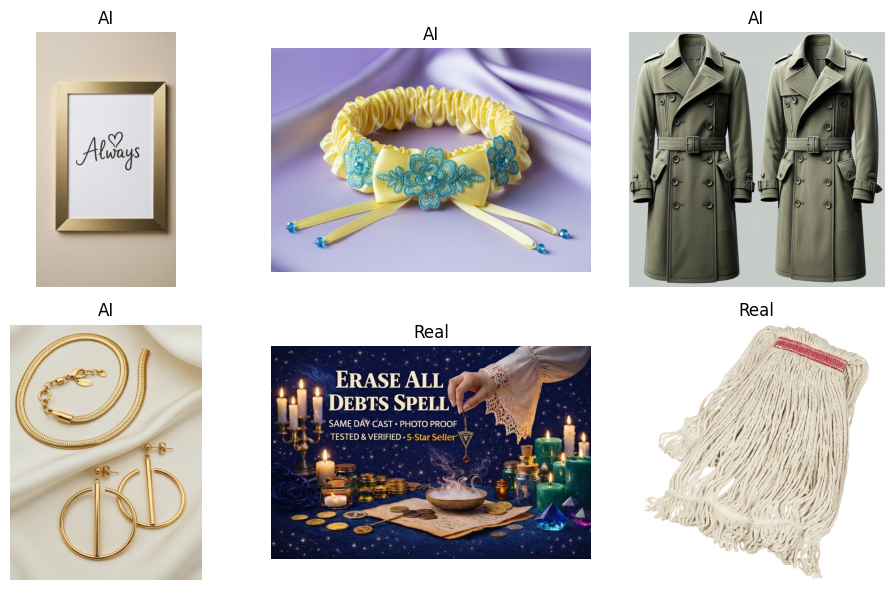

In [6]:
import matplotlib.pyplot as plt
import random
from PIL import Image

samples = train_df.sample(6, random_state=42)

plt.figure(figsize=(10,6))

for i, row in enumerate(samples.itertuples()):
    img = Image.open(row.path)
    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title("AI" if row.ground_truth==1 else "Real")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 5. Feature Extraction


For this baseline we simply flatten each image into a 1D vector of pixel values.  
Try various feature extraction techniques — there is plenty of room to improve!

In [7]:
import cv2
from tqdm import tqdm
import numpy as np

IMG_SIZE = (32, 32)  # small size to keep things fast

def extract_features(path: str) -> np.ndarray:
    try:
        img = Image.open(path).convert("RGB").resize(IMG_SIZE)
        return np.array(img).flatten().astype(np.float32) / 255.0
    except Exception:
        return np.zeros(IMG_SIZE[0] * IMG_SIZE[1] * 3, dtype=np.float32)


def build_matrix(df, label_col=None):
    X, y = [], []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        X.append(extract_features(row["path"]))
        if label_col:
            y.append(row[label_col])
    return np.array(X), np.array(y) if label_col else np.array(X)


print("Extracting train features...")
X_train, y_train = build_matrix(train_split, label_col="ground_truth")

print("Extracting val features...")
X_val, y_val = build_matrix(val_split, label_col="ground_truth")

print(f"Feature shape: {X_train.shape}")

Extracting train features...


100%|██████████| 3840/3840 [01:07<00:00, 57.11it/s]


Extracting val features...


100%|██████████| 960/960 [00:17<00:00, 56.02it/s]

Feature shape: (3840, 3072)


## 6. Train a Baseline Model

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

model.fit(X_train, y_train)
print("Model trained.")

Model trained.


## 7. Evaluate on Validation Set

              precision    recall  f1-score   support

   Authentic       0.65      0.69      0.67       497
AI-Generated       0.64      0.60      0.62       463

    accuracy                           0.65       960
   macro avg       0.65      0.65      0.65       960
weighted avg       0.65      0.65      0.65       960

Precision : 0.6422
Recall    : 0.6048
F1 Score  : 0.6229


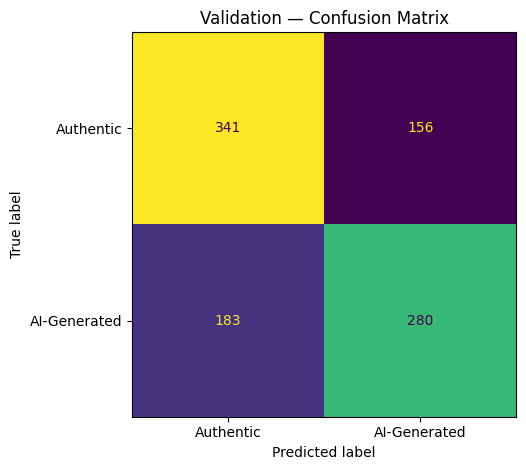

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score, precision_score, recall_score

y_pred = model.predict(X_val)

print(classification_report(y_val, y_pred, target_names=["Authentic", "AI-Generated"]))
print(f"Precision : {precision_score(y_val, y_pred):.4f}")
print(f"Recall    : {recall_score(y_val, y_pred):.4f}")
print(f"F1 Score  : {f1_score(y_val, y_pred):.4f}")

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_val, y_pred),
    display_labels=["Authentic", "AI-Generated"]
)
disp.plot(colorbar=False)
plt.title("Validation — Confusion Matrix")
plt.tight_layout()
plt.show()

## 8. Inference on Test Set

In [10]:
print("Extracting test features...")
X_test, _ = build_matrix(test_df)

test_df["prediction"] = model.predict(X_test)

print("Prediction distribution:")
print(test_df["prediction"].value_counts().rename({0: "authentic", 1: "ai_generated"}))

submission = test_df[["image_id", "prediction"]]
submission.to_csv("submission.csv", index=False)
print("\nSaved → submission.csv")
submission.head()

Extracting test features...


100%|██████████| 2058/2058 [00:35<00:00, 58.43it/s]


Prediction distribution:
prediction
authentic       1093
ai_generated     965
Name: count, dtype: int64

Saved → submission.csv


,image_id,prediction
0,3ecf1af5-6a8f-416a-9b4c-df9f2e0a0a80.jpg,1
1,2789b3fe-a337-4dc2-b42c-8bccde1f68fb.jpg,0
2,01a342c6-c3fc-4b55-8c22-13c1a556ba87.jpg,0
3,ac784910-b461-498d-b3a8-50b1e4116b11.jpg,0
4,6dcd4df6-7447-4bcf-a29b-f7f53b4c3ed4.jpg,0



## 9. What's Next?

This baseline is intentionally minimal — it is just a starting point. Here are some broad areas worth thinking about, but you are free to explore in any direction you choose:

- **Image representation** — how you turn an image into numbers matters a lot
- **Model choice** — different models have different strengths
- **Training strategy** — how you train can be just as important as what you train
- **Data** — think about what the data is telling you

There is no single right answer. Be creative, experiment, and have fun!

In [ ]:
print("Missing train paths:", train_df["path"].isnull().sum())
print("Missing test paths :", test_df["path"].isnull().sum())

Missing train paths: 0
Missing test paths : 0


# ViT

In [11]:
!pip install timm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import timm

In [12]:
class ImageDataset(Dataset):
  def __init__(self, df, transform = None, is_test = False):
    self.df = df
    self.transform = transform
    self.is_test = is_test

  def __len__(self):
    return len(self.df)

  def __getitem__(self, idx):
    row = self.df.iloc[idx]
    image = Image.open(row["path"]).convert("RGB")

    if self.transform:
      image = self.transform(image)

    if self.is_test:
      return image

    label = torch.tensor(row["ground_truth"], dtype=torch.float32)
    return image, label

In [13]:
train_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(0.2, 0.2),
    transforms.ToTensor(),
])

val_tfms = transforms.Compose([
     transforms.Resize((224, 224)),
     transforms.ToTensor(),
])


In [14]:
train_dataset = ImageDataset(train_split, transform=train_tfms)
val_dataset = ImageDataset(val_split, transform=val_tfms)

In [15]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=True)

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [17]:
model = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=1)
model = model.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [18]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5, weight_decay=1e-4)

In [19]:
import numpy as np
from sklearn.metrics import f1_score
epochs = 5
best_f1 = 0
best_preds_raw = None
best_labels = None

train_losses = []

for epoch in range(epochs):
  model.train()
  train_loss = 0

  for images, labels in train_loader:
    images = images.to(device)
    labels = labels.to(device).unsqueeze(1)

    optimizer.zero_grad()
    outputs = model(images)

    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    train_loss += loss.item()

  avg_loss = train_loss/len(train_loader)
  train_losses.append(avg_loss)

  model.eval()
  val_preds_raw = []
  val_labels = []

  with torch.no_grad():
    for images, labels in val_loader:
      images = images.to(device)
      outputs = model(images)

      preds = torch.sigmoid(outputs).cpu().numpy()
      val_preds_raw.extend(preds)
      val_labels.extend(labels.numpy())

  val_preds_raw = np.array(val_preds_raw)
  val_labels = np.array(val_labels)

  val_preds = (val_preds_raw>0.5).astype(int)
  f1 = f1_score(val_labels, val_preds)

  print(f"Epoch {epoch+1} | Loss: {train_loss:.4f} | F1: {f1:.4f}")

  if f1 > best_f1:
    best_f1 = f1
    best_preds_raw = val_preds_raw.copy()
    best_labels = val_labels.copy()
    torch.save(model.state_dict(),"best_vit.pth")

print(f"\nBest F1 : {best_f1:.4f}")

Epoch 1 | Loss: 123.1103 | F1: 0.8227
Epoch 2 | Loss: 65.6355 | F1: 0.8649
Epoch 3 | Loss: 30.0404 | F1: 0.8721
Epoch 4 | Loss: 16.7336 | F1: 0.8457
Epoch 5 | Loss: 10.7623 | F1: 0.8509

Best F1 : 0.8721


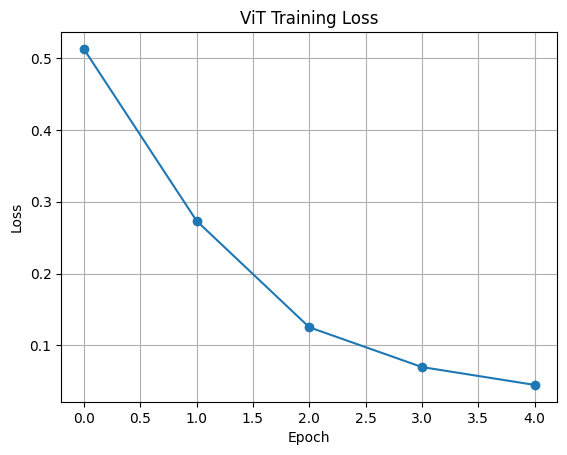

In [20]:
import matplotlib.pyplot as plt
plt.plot(train_losses, marker='o')
plt.title("ViT Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()

In [21]:
best_thresh = 0.5
best_f1_thresh = 0

for t in np.arange(0.3,0.7,0.05):
  preds = (best_preds_raw > t).astype(int)
  f1 = f1_score(best_labels, preds)

  print(f"Threshold {t:.2f} -> F1: {f1:.4f}")

  if f1 > best_f1_thresh:
    best_f1_thresh = f1
    best_thresh = t

print("\nBest threshold :", best_thresh)
print("\nBest F1 after threshold tunning :", best_f1_thresh)

Threshold 0.30 -> F1: 0.8656
Threshold 0.35 -> F1: 0.8734
Threshold 0.40 -> F1: 0.8717
Threshold 0.45 -> F1: 0.8684
Threshold 0.50 -> F1: 0.8721
Threshold 0.55 -> F1: 0.8628
Threshold 0.60 -> F1: 0.8556
Threshold 0.65 -> F1: 0.8547

Best threshold : 0.35

Best F1 after threshold tunning : 0.8733798604187437


In [22]:
print(test_df.shape)

(2058, 3)


In [23]:
test_dataset = ImageDataset(test_df, transform=val_tfms, is_test=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [24]:
model.load_state_dict(torch.load("best_vit.pth"))
model.eval()

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False

In [25]:
test_preds = []

with torch.no_grad():
  for images in test_loader:
    images = images.to(device)
    outputs = model(images)
    preds = torch.sigmoid(outputs).cpu().numpy()
    test_preds.extend(preds)

best_thresh = 0.3
test_preds = (np.array(test_preds)> best_thresh).astype(int)

In [26]:
print(len(test_df))
print(len(test_preds))

2058
2058


In [27]:
submission = test_df.copy()
submission["label"] = test_preds
submission = submission[["image_id","label"]]

submission.to_csv("submission_vit.csv", index=False)
print("Saved -> submission_vit.csv")
submission.head(20)

Saved -> submission_vit.csv


,image_id,label
0,3ecf1af5-6a8f-416a-9b4c-df9f2e0a0a80.jpg,1
1,2789b3fe-a337-4dc2-b42c-8bccde1f68fb.jpg,0
2,01a342c6-c3fc-4b55-8c22-13c1a556ba87.jpg,0
3,ac784910-b461-498d-b3a8-50b1e4116b11.jpg,0
4,6dcd4df6-7447-4bcf-a29b-f7f53b4c3ed4.jpg,0
5,73b2089b-34a5-49de-a98b-2325512322f1.jpg,0
6,8bb3958b-3487-4ad4-86cc-5c391e3bd9a4.jpg,1
7,23a0595f-7b9e-47ce-ae12-07a83a00c189.jpg,1
8,32e05946-83ff-4780-9090-4ad99ccd4134.jpg,0
9,674a7ded-31e4-41b1-a7cf-4a6c04fd4af1.jpg,1


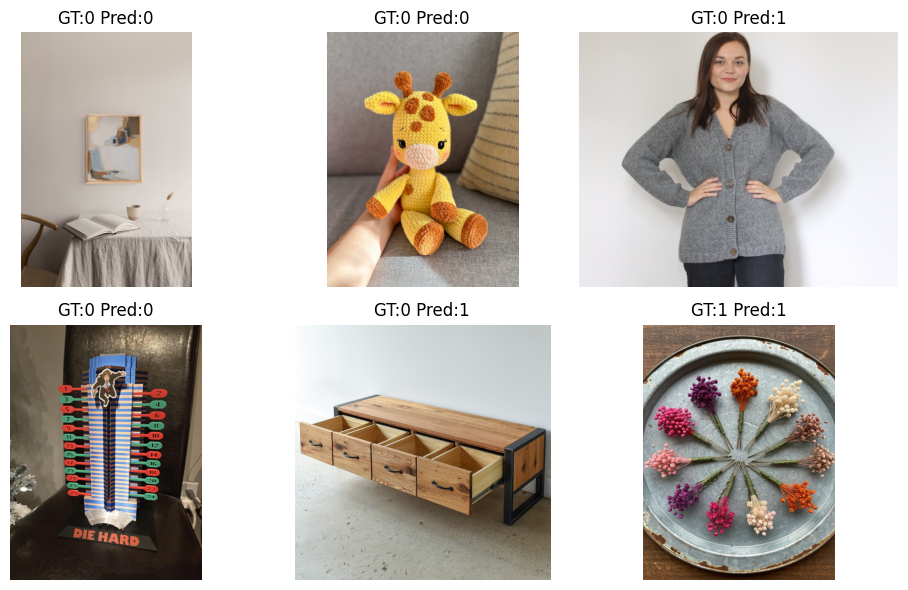

In [28]:
# ViT Prediction Visualization

import random

samples = val_split.sample(6, random_state=42)
plt.figure(figsize=(10,6))

# model.load()_state_dict(torch.load("best_vit.pth"))
# model.eval()

for i, row in enumerate(samples.itertuples()):
  img = Image.open(row.path)

  x = val_tfms(img).unsqueeze(0).to(device)
  pred = torch.sigmoid(model(x)).item()
  label = 1 if pred > best_thresh else 0

  plt.subplot(2,3,i+1)
  plt.imshow(img)
  plt.title(f"GT:{row.ground_truth} Pred:{label}")
  plt.axis("off")

plt.tight_layout()
plt.show()



Model 2 : EFFICIENTNET-B4

In [29]:
train_tfms_ef = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(0.3, 0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_tfms_ef = transforms.Compose([
     transforms.Resize((224, 224)),
     transforms.ToTensor(),
     transforms.Normalize([0.485, 0.456, 0.406],
                          [0.229, 0.224, 0.225])
])


In [30]:
train_dataset_ef = ImageDataset(train_split, transform=train_tfms_ef)
val_dataset_ef = ImageDataset(val_split, transform=val_tfms_ef)

In [31]:
train_loader_ef = DataLoader(train_dataset_ef, batch_size=8, shuffle=True)
val_loader_ef = DataLoader(val_dataset_ef, batch_size=8, shuffle=False)

In [32]:
model_ef=timm.create_model('efficientnet_b4',pretrained=True,num_classes=1)
model_ef=model_ef.to(device)

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

Loss+optimizer

In [33]:
criterion_ef=nn.BCEWithLogitsLoss()

optimizer_ef=torch.optim.AdamW(
    model_ef.parameters(),
    lr=7e-5,
    weight_decay=1e-4
)

Training loop

In [34]:
import numpy as np
from sklearn.metrics import f1_score

epochs = 6
best_f1_ef = 0
best_preds_raw_ef = None
best_labels_ef = None


train_losses_ef = []

for epoch in range(epochs):
    model_ef.train()
    train_loss = 0

    for images, labels in train_loader_ef:
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)

        optimizer_ef.zero_grad()
        outputs = model_ef(images)

        loss = criterion_ef(outputs, labels)
        loss.backward()
        optimizer_ef.step()

        train_loss += loss.item()


    avg_loss = train_loss / len(train_loader_ef)
    train_losses_ef.append(avg_loss)

    # Validation
    model_ef.eval()
    val_preds_raw_ef = []
    val_labels_ef = []

    with torch.no_grad():
        for images, labels in val_loader_ef:
            images = images.to(device)
            outputs = model_ef(images)

            preds = torch.sigmoid(outputs).cpu().numpy()
            val_preds_raw_ef.extend(preds)
            val_labels_ef.extend(labels.numpy())

    val_preds_raw_ef = np.array(val_preds_raw_ef)
    val_labels_ef = np.array(val_labels_ef)

    val_preds_ef = (val_preds_raw_ef > 0.5).astype(int)
    f1_ef = f1_score(val_labels_ef, val_preds_ef)

    print(f"[EffNet] Epoch {epoch+1} | Loss: {avg_loss:.4f} | F1: {f1_ef:.4f}")

    if f1_ef > best_f1_ef:
        best_f1_ef = f1_ef
        best_preds_raw_ef = val_preds_raw_ef.copy()
        best_labels_ef = val_labels_ef.copy()
        torch.save(model_ef.state_dict(), "best_effnet.pth")

print(f"\nBest F1 : {best_f1_ef:.4f}")

[EffNet] Epoch 1 | Loss: 0.9195 | F1: 0.6233
[EffNet] Epoch 2 | Loss: 0.6364 | F1: 0.6686
[EffNet] Epoch 3 | Loss: 0.5622 | F1: 0.6547
[EffNet] Epoch 4 | Loss: 0.4779 | F1: 0.6944
[EffNet] Epoch 5 | Loss: 0.4311 | F1: 0.7192
[EffNet] Epoch 6 | Loss: 0.4030 | F1: 0.7242

Best F1 : 0.7242


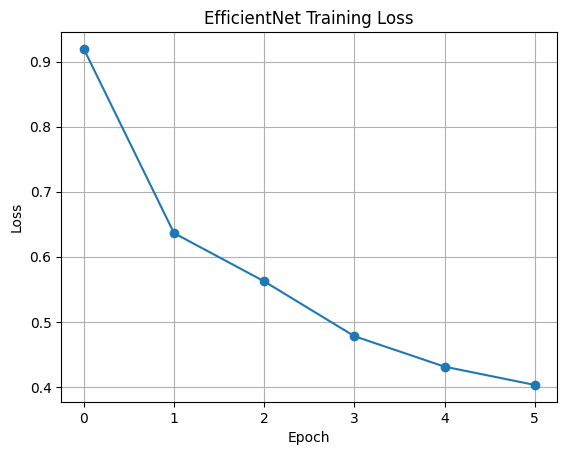

In [35]:
import matplotlib.pyplot as plt

plt.plot(train_losses_ef, marker='o')
plt.title("EfficientNet Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()

Threshold tuning

In [36]:
best_thresh_ef = 0.5
best_f1_thresh_ef = 0

for t in np.arange(0.3,0.7,0.05):
  preds = (best_preds_raw_ef > t).astype(int)
  f1 = f1_score(best_labels_ef, preds)

  print(f"[EffNet] Threshold {t:.2f} -> F1: {f1:.4f}")

  if f1 > best_f1_thresh_ef:
    best_f1_thresh_ef = f1
    best_thresh_ef = t

print("\nBest threshold :", best_thresh_ef)
print("\nBest F1 after threshold tunning :", best_f1_thresh_ef)

[EffNet] Threshold 0.30 -> F1: 0.7166
[EffNet] Threshold 0.35 -> F1: 0.7134
[EffNet] Threshold 0.40 -> F1: 0.7093
[EffNet] Threshold 0.45 -> F1: 0.7167
[EffNet] Threshold 0.50 -> F1: 0.7242
[EffNet] Threshold 0.55 -> F1: 0.7202
[EffNet] Threshold 0.60 -> F1: 0.7159
[EffNet] Threshold 0.65 -> F1: 0.7072

Best threshold : 0.49999999999999994

Best F1 after threshold tunning : 0.724172517552658


In [37]:
test_dataset_ef = ImageDataset(test_df, transform=val_tfms_ef, is_test=True)
test_loader_ef = DataLoader(test_dataset_ef, batch_size=16, shuffle=False)

Test predicitions

In [38]:
model_ef.load_state_dict(torch.load("best_effnet.pth"))
model_ef.eval()

EfficientNet(
  (conv_stem): Conv2d(3, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNormAct2d(
    48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=48, bias=False)
        (bn1): BatchNormAct2d(
          48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(48, 12, kernel_size=(1, 1), stride=(1, 1))
          (act1): SiLU(inplace=True)
          (conv_expand): Conv2d(12, 48, kernel_size=(1, 1), stride=(1, 1))
          (gate): Sigmoid()
        )
        (conv_pw): Conv2d(48, 24, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (b

In [39]:
test_preds_ef = []

with torch.no_grad():
  for images in test_loader_ef:
    images = images.to(device)
    outputs = model_ef(images)
    preds = torch.sigmoid(outputs).cpu().numpy()
    test_preds_ef.extend(preds)

test_preds_ef = (np.array(test_preds_ef)> best_thresh_ef).astype(int)

In [40]:
print(len(test_df))
print(len(test_preds_ef))

2058
2058


In [41]:
submission_ef = test_df.copy()
submission_ef["label"] = test_preds_ef
submission_ef = submission_ef[["image_id","label"]]

submission_ef.to_csv("submission_effnet.csv", index=False)
print("Saved -> submission_effnet.csv")

Saved -> submission_effnet.csv


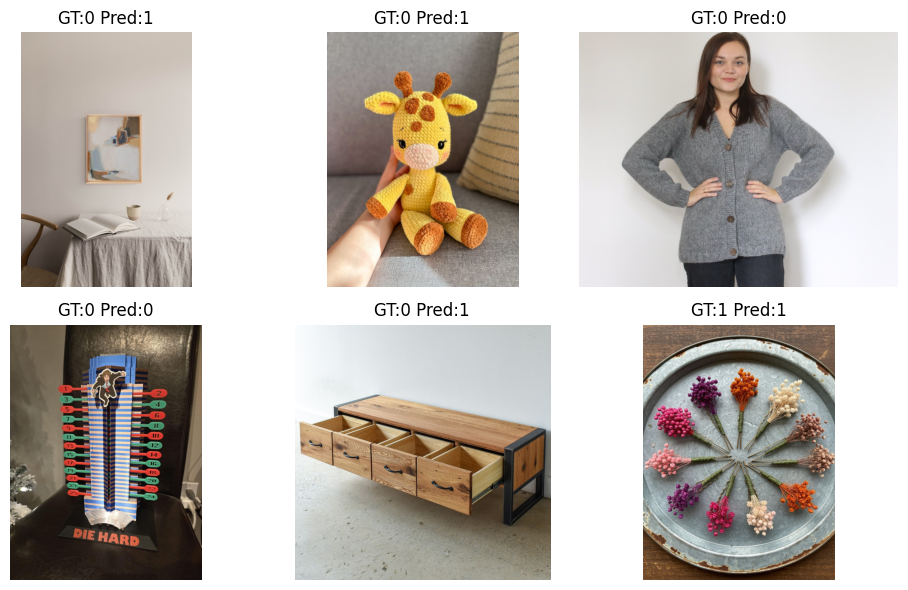

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

plt.figure(figsize=(10,6))

model_ef.eval()

for i, row in enumerate(samples.itertuples()):
    img = Image.open(row.path).convert("RGB")

    # apply EfficientNet transform
    x = val_tfms_ef(img).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = torch.sigmoid(model_ef(x)).item()

    label = 1 if pred > 0.5 else 0

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(f"GT:{row.ground_truth} Pred:{label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

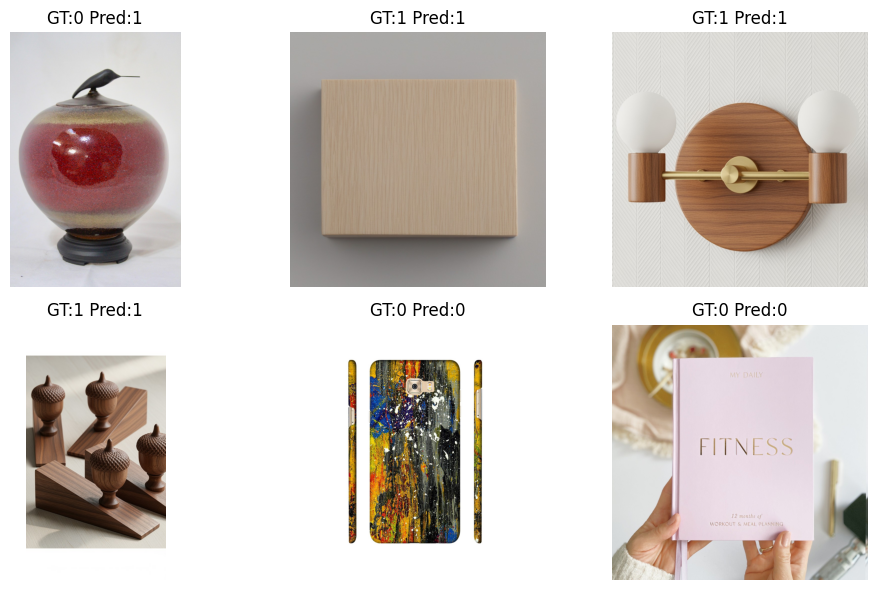

In [ ]:
samples = val_split.sample(6)

plt.figure(figsize=(10,6))
model_ef.load_state_dict(torch.load("best_effnet.pth"))
model_ef.eval()

for i, row in enumerate(samples.itertuples()):
  img = Image.open(row.path)

  x = val_tfms_ef(img).unsqueeze(0).to(device)
  pred = torch.sigmoid(model_ef(x)).item()
  label = 1 if pred > best_thresh_ef else 0

  plt.subplot(2,3,i+1)
  plt.imshow(img)
  plt.title(f"GT:{row.ground_truth} Pred:{label}")
  plt.axis("off")

plt.tight_layout()
plt.show()

Ensemble

In [ ]:
vit_preds=pd.read_csv("submission_vit.csv")["label"].values
eff_pred=pd.read_csv("submission_effnet.csv")["label"].values

final_preds=((0.8*vit_preds+0.2*eff_pred)>0.5).astype(int)

print(len(vit_preds), len(eff_pred))

final_preds=((vit_preds + eff_pred) / 2 > 0.5).astype(int)

submission_final=test_df.copy()
submission_final["label"] = final_preds
submission_final = submission_final[["image_id","label"]]

submission_final.to_csv("submission_final.csv", index=False)
print("Saved -> submission_final.csv")


2058 2058
Saved -> submission_final.csv


In [ ]:


vit_probs = []
eff_probs = []
y_true = []


model.load_state_dict(torch.load("best_vit.pth"))
model.eval()

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.sigmoid(outputs).cpu().numpy()

        vit_probs.extend(preds)
        y_true.extend(labels.numpy())

vit_probs = np.array(vit_probs)
y_true = np.array(y_true)


model_ef.load_state_dict(torch.load("best_effnet.pth"))
model_ef.eval()

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model_ef(images)
        preds = torch.sigmoid(outputs).cpu().numpy()

        eff_probs.extend(preds)

eff_probs = np.array(eff_probs)


ensemble_probs = (vit_probs + eff_probs) / 2
ensemble_preds = (ensemble_probs > 0.5).astype(int)

from sklearn.metrics import f1_score, precision_score, recall_score

print("Ensemble Performance on Validation:")
print(f"F1 Score  : {f1_score(y_true, ensemble_preds):.4f}")
print(f"Precision : {precision_score(y_true, ensemble_preds):.4f}")
print(f"Recall    : {recall_score(y_true, ensemble_preds):.4f}")

Ensemble Performance on Validation:
F1 Score  : 0.8456
Precision : 0.8340
Recall    : 0.8575


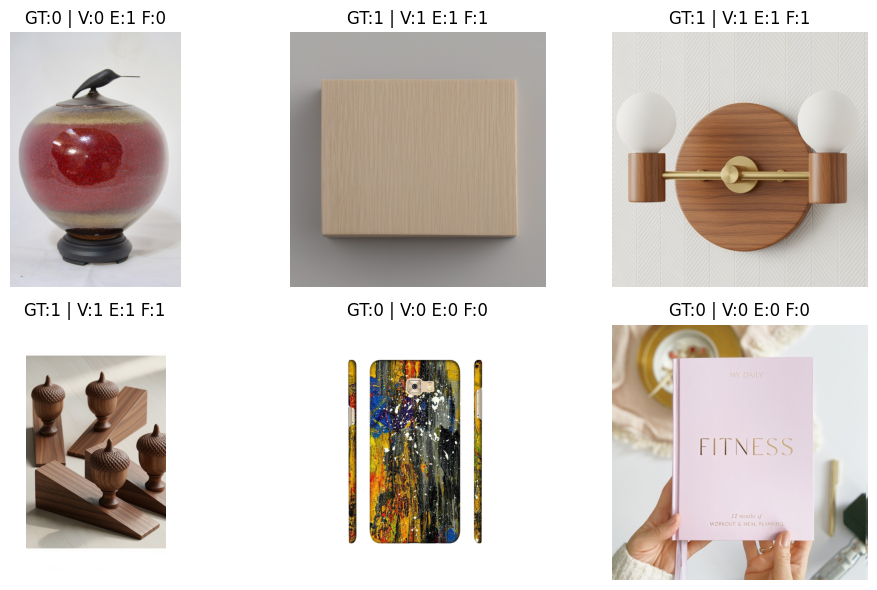

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

plt.figure(figsize=(10,6))


model.eval()
model_ef.eval()

for i, row in enumerate(samples.itertuples()):
    img = Image.open(row.path).convert("RGB")

    # --- ViT prediction ---
    x_vit = val_tfms(img).unsqueeze(0).to(device)
    with torch.no_grad():
        vit_pred = torch.sigmoid(model(x_vit)).item()

    # --- EffNet prediction ---
    x_ef = val_tfms_ef(img).unsqueeze(0).to(device)
    with torch.no_grad():
        eff_pred = torch.sigmoid(model_ef(x_ef)).item()

    # --- Ensemble (weighted) ---
    final_pred = 1 if (0.8 * vit_pred + 0.2 * eff_pred) > 0.5 else 0

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(f"GT:{row.ground_truth} | V:{int(vit_pred>0.5)} E:{int(eff_pred>0.5)} F:{final_pred}")
    plt.axis("off")

plt.tight_layout()
plt.show()